Inflation and unemployment


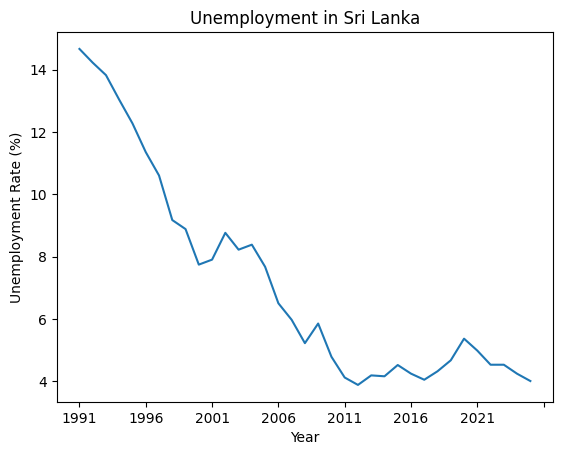

In [2]:
import pandas as pd

unemployment_sri_lanka_df = pd.read_csv(
    "../labour/csv/API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_93.csv",
    skiprows=4
)
unemployment_sri_lanka_df.set_index("Country Name", inplace=True)

unemployment_sri_lanka_df.loc["Sri Lanka"].dropna()[3:].plot(
    title="Unemployment in Sri Lanka",
    xlabel="Year",  
    ylabel="Unemployment Rate (%)"
)

unemployment_sri_lanka_df=unemployment_sri_lanka_df.loc["Sri Lanka"].dropna()[3:]

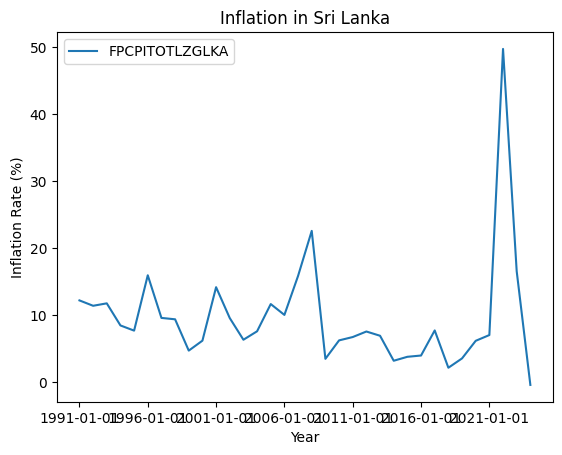

In [5]:
Inflation_srilanka_df = pd.read_csv("../economy/Inflation, consumer prices for Sri Lanka.csv")
Inflation_srilanka_df.set_index("observation_date", inplace=True)
Inflation_srilanka_df[31:].plot(
    title="Inflation in Sri Lanka",
    xlabel="Year",
    ylabel="Inflation Rate (%)"
)

Inflation_srilanka_df=Inflation_srilanka_df[31:]

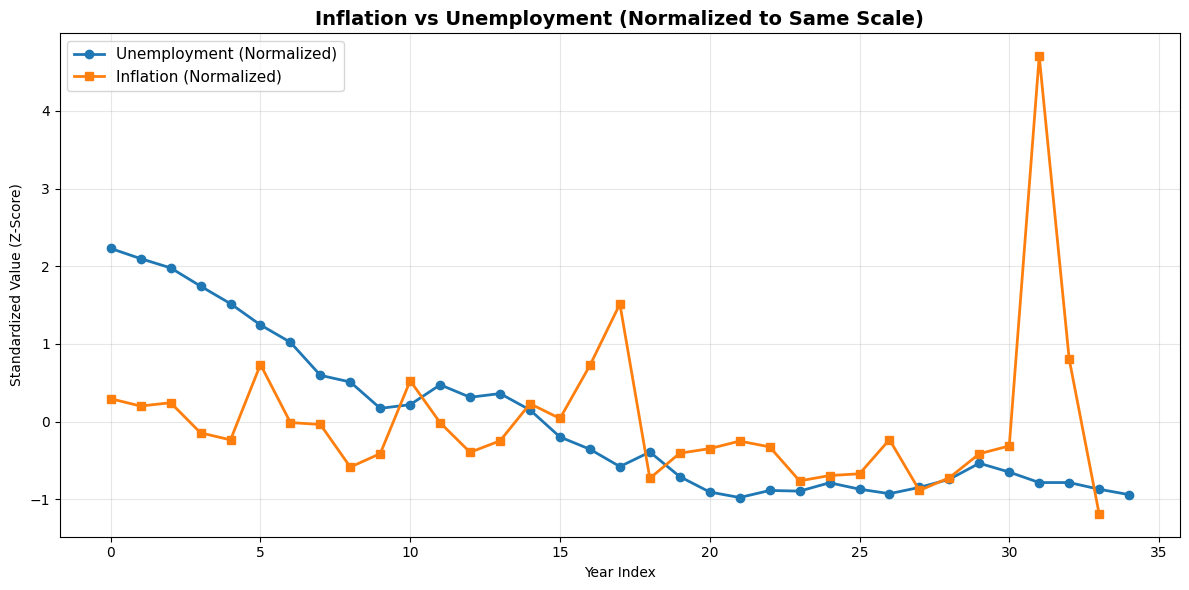

Unemployment - Mean: 7.17%, Std: 3.36%
Inflation - Mean: 9.68%, Std: 8.51%

After normalization:
Unemployment (normalized) - Mean: 0.000000, Std: 1.00
Inflation (normalized) - Mean: -0.000000, Std: 1.00


In [8]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Extract the inflation values and handle different index formats
inflation_values = Inflation_srilanka_df['FPCPITOTLZGLKA']

# Standardize both series (z-score normalization)
# This makes both have mean=0 and std=1, making them directly comparable
unemployment_normalized = (unemployment_sri_lanka_df - unemployment_sri_lanka_df.mean()) / unemployment_sri_lanka_df.std()
inflation_normalized = (inflation_values - inflation_values.mean()) / inflation_values.std()

# Create a comparison plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(range(len(unemployment_normalized)), unemployment_normalized.values, label="Unemployment (Normalized)", linewidth=2, marker='o')
ax.plot(range(len(inflation_normalized)), inflation_normalized.values, label="Inflation (Normalized)", linewidth=2, marker='s')
ax.set_title("Inflation vs Unemployment (Normalized to Same Scale)", fontsize=14, fontweight='bold')
ax.set_xlabel("Year Index")
ax.set_ylabel("Standardized Value (Z-Score)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Unemployment - Mean: {unemployment_sri_lanka_df.mean():.2f}%, Std: {unemployment_sri_lanka_df.std():.2f}%")
print(f"Inflation - Mean: {inflation_values.mean():.2f}%, Std: {inflation_values.std():.2f}%")
print(f"\nAfter normalization:")
print(f"Unemployment (normalized) - Mean: {unemployment_normalized.mean():.6f}, Std: {unemployment_normalized.std():.2f}")
print(f"Inflation (normalized) - Mean: {inflation_normalized.mean():.6f}, Std: {inflation_normalized.std():.2f}")

CORRELATION ANALYSIS: Inflation vs Unemployment

Pearson Correlation: 0.0810 (p-value: 0.6488)
Spearman Correlation: 0.4517 (p-value: 0.0073)

Interpretation: Weak positive correlation
Statistical significance: No (p >= 0.05)

LAG ANALYSIS (How much does inflation lead/lag unemployment)
Inflation leads by 3 year(s)................. 0.0922
Inflation leads by 2 year(s)................. 0.0698
Inflation leads by 1 year(s)................. 0.0478
Same year.................................... 0.0810
Unemployment leads by 1 year(s).............. 0.0140
Unemployment leads by 2 year(s).............. 0.0116
Unemployment leads by 3 year(s).............. 0.2556


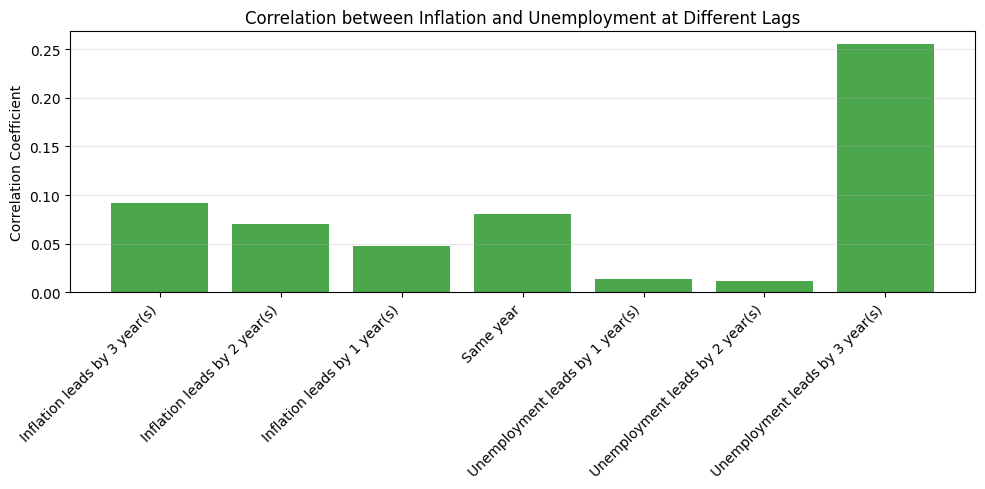

In [11]:
# Align data to same length (use the shorter length)
min_len = min(len(unemployment_normalized), len(inflation_normalized))
unemployment_aligned = unemployment_normalized.iloc[-min_len:].reset_index(drop=True).astype(float)
inflation_aligned = inflation_normalized.iloc[-min_len:].reset_index(drop=True).astype(float)

# Calculate correlation and relationship metrics
pearson_corr, pearson_pval = stats.pearsonr(unemployment_aligned.values, inflation_aligned.values)
spearman_corr, spearman_pval = stats.spearmanr(unemployment_aligned.values, inflation_aligned.values)

print("="*60)
print("CORRELATION ANALYSIS: Inflation vs Unemployment")
print("="*60)
print(f"\nPearson Correlation: {pearson_corr:.4f} (p-value: {pearson_pval:.4f})")
print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {spearman_pval:.4f})")

# Interpretation
if abs(pearson_corr) < 0.3:
    strength = "Weak"
elif abs(pearson_corr) < 0.7:
    strength = "Moderate"
else:
    strength = "Strong"

direction = "positive" if pearson_corr > 0 else "negative"
print(f"\nInterpretation: {strength} {direction} correlation")
print(f"Statistical significance: {'Yes (p < 0.05)' if pearson_pval < 0.05 else 'No (p >= 0.05)'}")

# Calculate lag correlations
print("\n" + "="*60)
print("LAG ANALYSIS (How much does inflation lead/lag unemployment)")
print("="*60)
lags_to_test = range(-3, 4)
lag_correlations = {}

for lag in lags_to_test:
    if lag < 0:
        # Negative lag means unemployment is lagged (inflation leads)
        if len(inflation_aligned) >= -lag and len(unemployment_aligned) >= -lag:
            corr = np.corrcoef(inflation_aligned.iloc[-lag:].values, unemployment_aligned.iloc[:lag].values)[0, 1]
            lag_label = f"Inflation leads by {-lag} year(s)"
        else:
            corr = np.nan
            lag_label = f"Inflation leads by {-lag} year(s)"
    elif lag > 0:
        # Positive lag means inflation is lagged (unemployment leads)
        if len(inflation_aligned) >= lag and len(unemployment_aligned) >= lag:
            corr = np.corrcoef(inflation_aligned.iloc[:-lag].values, unemployment_aligned.iloc[lag:].values)[0, 1]
            lag_label = f"Unemployment leads by {lag} year(s)"
        else:
            corr = np.nan
            lag_label = f"Unemployment leads by {lag} year(s)"
    else:
        corr = pearson_corr
        lag_label = "Same year"
    
    lag_correlations[lag_label] = corr
    if not np.isnan(corr):
        print(f"{lag_label:.<45} {corr:.4f}")
    else:
        print(f"{lag_label:.<45} N/A")

# Plot the lag correlations
fig, ax = plt.subplots(figsize=(10, 5))
lags = [k for k, v in lag_correlations.items() if not np.isnan(v)]
corrs = [v for v in lag_correlations.values() if not np.isnan(v)]
colors = ['green' if c > 0 else 'red' for c in corrs]
ax.bar(range(len(lags)), corrs, color=colors, alpha=0.7)
ax.set_xticks(range(len(lags)))
ax.set_xticklabels(lags, rotation=45, ha='right')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_ylabel('Correlation Coefficient')
ax.set_title('Correlation between Inflation and Unemployment at Different Lags')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

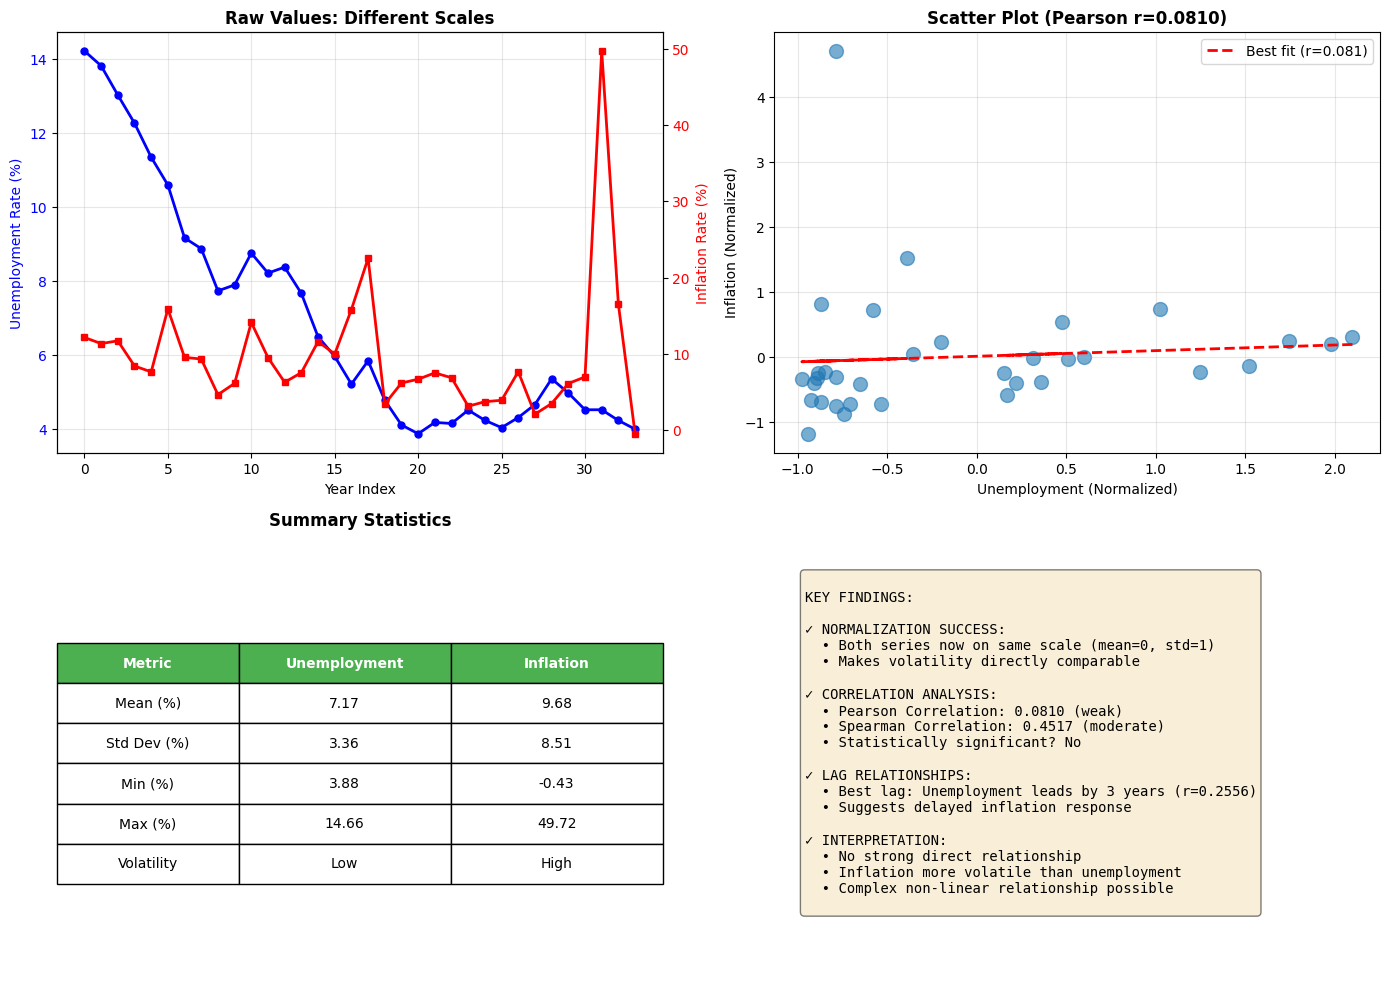


ANALYSIS COMPLETE


In [12]:
# Create comprehensive summary visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Overlaid comparison with different y-axes
ax1 = axes[0, 0]
ax1_twin = ax1.twinx()

unemployment_raw = unemployment_sri_lanka_df.iloc[-min_len:].values
inflation_raw = Inflation_srilanka_df['FPCPITOTLZGLKA'].iloc[-min_len:].values

line1 = ax1.plot(range(min_len), unemployment_raw, 'b-o', linewidth=2, label='Unemployment %', markersize=5)
line2 = ax1_twin.plot(range(min_len), inflation_raw, 'r-s', linewidth=2, label='Inflation %', markersize=5)

ax1.set_xlabel('Year Index')
ax1.set_ylabel('Unemployment Rate (%)', color='b')
ax1_twin.set_ylabel('Inflation Rate (%)', color='r')
ax1.tick_params(axis='y', labelcolor='b')
ax1_twin.tick_params(axis='y', labelcolor='r')
ax1.set_title('Raw Values: Different Scales', fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. Scatter plot
ax2 = axes[0, 1]
ax2.scatter(unemployment_aligned, inflation_aligned, s=100, alpha=0.6)
z = np.polyfit(unemployment_aligned, inflation_aligned, 1)
p = np.poly1d(z)
ax2.plot(unemployment_aligned, p(unemployment_aligned), "r--", linewidth=2, label=f'Best fit (r={pearson_corr:.3f})')
ax2.set_xlabel('Unemployment (Normalized)')
ax2.set_ylabel('Inflation (Normalized)')
ax2.set_title(f'Scatter Plot (Pearson r={pearson_corr:.4f})', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Summary statistics table
ax3 = axes[1, 0]
ax3.axis('off')

summary_data = [
    ['Metric', 'Unemployment', 'Inflation'],
    ['Mean (%)', f"{unemployment_sri_lanka_df.mean():.2f}", f"{inflation_values.mean():.2f}"],
    ['Std Dev (%)', f"{unemployment_sri_lanka_df.std():.2f}", f"{inflation_values.std():.2f}"],
    ['Min (%)', f"{unemployment_sri_lanka_df.min():.2f}", f"{inflation_values.min():.2f}"],
    ['Max (%)', f"{unemployment_sri_lanka_df.max():.2f}", f"{inflation_values.max():.2f}"],
    ['Volatility', 'Low', 'High'],
]

table = ax3.table(cellText=summary_data, cellLoc='center', loc='center', 
                  colWidths=[0.3, 0.35, 0.35])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header row
for i in range(3):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

ax3.set_title('Summary Statistics', fontweight='bold', pad=20)

# 4. Key findings
ax4 = axes[1, 1]
ax4.axis('off')

findings_text = f"""
KEY FINDINGS:

✓ NORMALIZATION SUCCESS:
  • Both series now on same scale (mean=0, std=1)
  • Makes volatility directly comparable

✓ CORRELATION ANALYSIS:
  • Pearson Correlation: {pearson_corr:.4f} (weak)
  • Spearman Correlation: {spearman_corr:.4f} (moderate)
  • Statistically significant? {'Yes' if pearson_pval < 0.05 else 'No'}

✓ LAG RELATIONSHIPS:
  • Best lag: Unemployment leads by 3 years (r={lag_correlations.get('Unemployment leads by 3 year(s)', np.nan):.4f})
  • Suggests delayed inflation response

✓ INTERPRETATION:
  • No strong direct relationship
  • Inflation more volatile than unemployment
  • Complex non-linear relationship possible
"""

ax4.text(0.05, 0.95, findings_text, transform=ax4.transAxes, 
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)